# 0 IMPORTACIÓN DE BIBLIOTECAS Y LIBRERÍAS

In [1]:
import pandas as pd
import missingno as msno
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import skew, kurtosis, norm
from sklearn.model_selection import train_test_split
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import seaborn as sns
from sklearn.metrics import silhouette_score, accuracy_score, f1_score, precision_score, recall_score
from sklearn.tree import DecisionTreeClassifier, export_text
from sklearn import tree 
import joblib

# 1 INGESTIÓN O CARGA DE DATOS

In [2]:
df_original = pd.read_csv(r"https://breathecode.herokuapp.com/asset/internal-link?id=809&path=housing.csv")

print(f"TAMAÑO DEL DATASET: {df_original.shape[0]} filas x {df_original.shape[1]} columnas")

TAMAÑO DEL DATASET: 20640 filas x 9 columnas


# 2 INSPECCIÓN INICIAL

## 2.1 VISUALIZACIÓN DE TODAS LAS COLUMNAS 

In [3]:
pd.set_option('display.max_columns', None)
# Esto sirve para que me muestre todas las columnas cuando un DataSet es muy ancho o con muchas columnas 
# Con el (None) le digo que me muestre todas las columnas sin limitación
df_original.head(3)

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521


## 2.2 INFORMACIÓN DEL DATASET 

In [4]:
# Información general del dataset
print("INFORMACIÓN GENERAL:")
print("="*80)
df_original.info()

print("\n" + "="*80)

# Lista de columnas
print("COLUMNAS DEL DATASET:\n")
print(df_original.columns.tolist())

INFORMACIÓN GENERAL:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   MedInc       20640 non-null  float64
 1   HouseAge     20640 non-null  float64
 2   AveRooms     20640 non-null  float64
 3   AveBedrms    20640 non-null  float64
 4   Population   20640 non-null  float64
 5   AveOccup     20640 non-null  float64
 6   Latitude     20640 non-null  float64
 7   Longitude    20640 non-null  float64
 8   MedHouseVal  20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB

COLUMNAS DEL DATASET:

['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude', 'MedHouseVal']


# 3 CRIBADO DE VARIABLES 

## 3.1 DFINICIÓN DE OBJETIVO DE ESTUDIO 

Queremos ser capaces de clasificar casas según su la región en la que se encuentren y del ingreso medio. Para ello, utilizaremos el famoso conjunto de datos California Housing. Se construyó utilizando los datos del censo de California de 1990. Contiene una fila por grupo de bloques censales. Un grupo de bloques es la unidad geográfica más pequeña para la que se publican datos del censo de USA. 

#### En este caso solo nos interesan las columnas Latitude, Longitude y MedInc.

## 3.2 CREACIÓN DE DATASET PARA TRABAJAR

In [5]:
df = df_original.copy()

## 3.2 ELIMINAR LA COLUMNAS INNECESARIAS

In [6]:
df = df[["MedInc", "Latitude", "Longitude"]]
df.head(3)

,MedInc,Latitude,Longitude
0,8.3252,37.88,-122.23
1,8.3014,37.86,-122.22
2,7.2574,37.85,-122.24


## 3.3 DESCRIPCIÓN GENERAL DE COLUMNAS SELECCIONADAS

In [7]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
MedInc,20640.0,3.870671,1.899822,0.4999,2.5634,3.5348,4.74325,15.0001
Latitude,20640.0,35.631861,2.135952,32.5400,33.9300,34.2600,37.71000,41.9500
Longitude,20640.0,-119.569704,2.003532,-124.3500,-121.8000,-118.4900,-118.01000,-114.3100


## 3.4 VERIFICACIÓN DE DATOS FALTANTES EN COLUMNAS

In [8]:
df.isnull().sum()

MedInc       0
Latitude     0
Longitude    0
dtype: int64

## 3.5 VERIFICACIÓN DE DATOS FALTANTES EN FILAS > 40%

In [9]:
df_filas_faltantes = (df.T.isnull().sum()* 100 / len(df)).round(2)
if df_filas_faltantes[df_filas_faltantes > 0.40].any():
    print(df_filas_faltantes[df_filas_faltantes > 0.40])
else:
    print("No hay Filas con Valores Faltantes > 40 % en el DataSet")

No hay Filas con Valores Faltantes > 40 % en el DataSet


## 3.6 GRÁFICA DE VALORES FALTANTES 

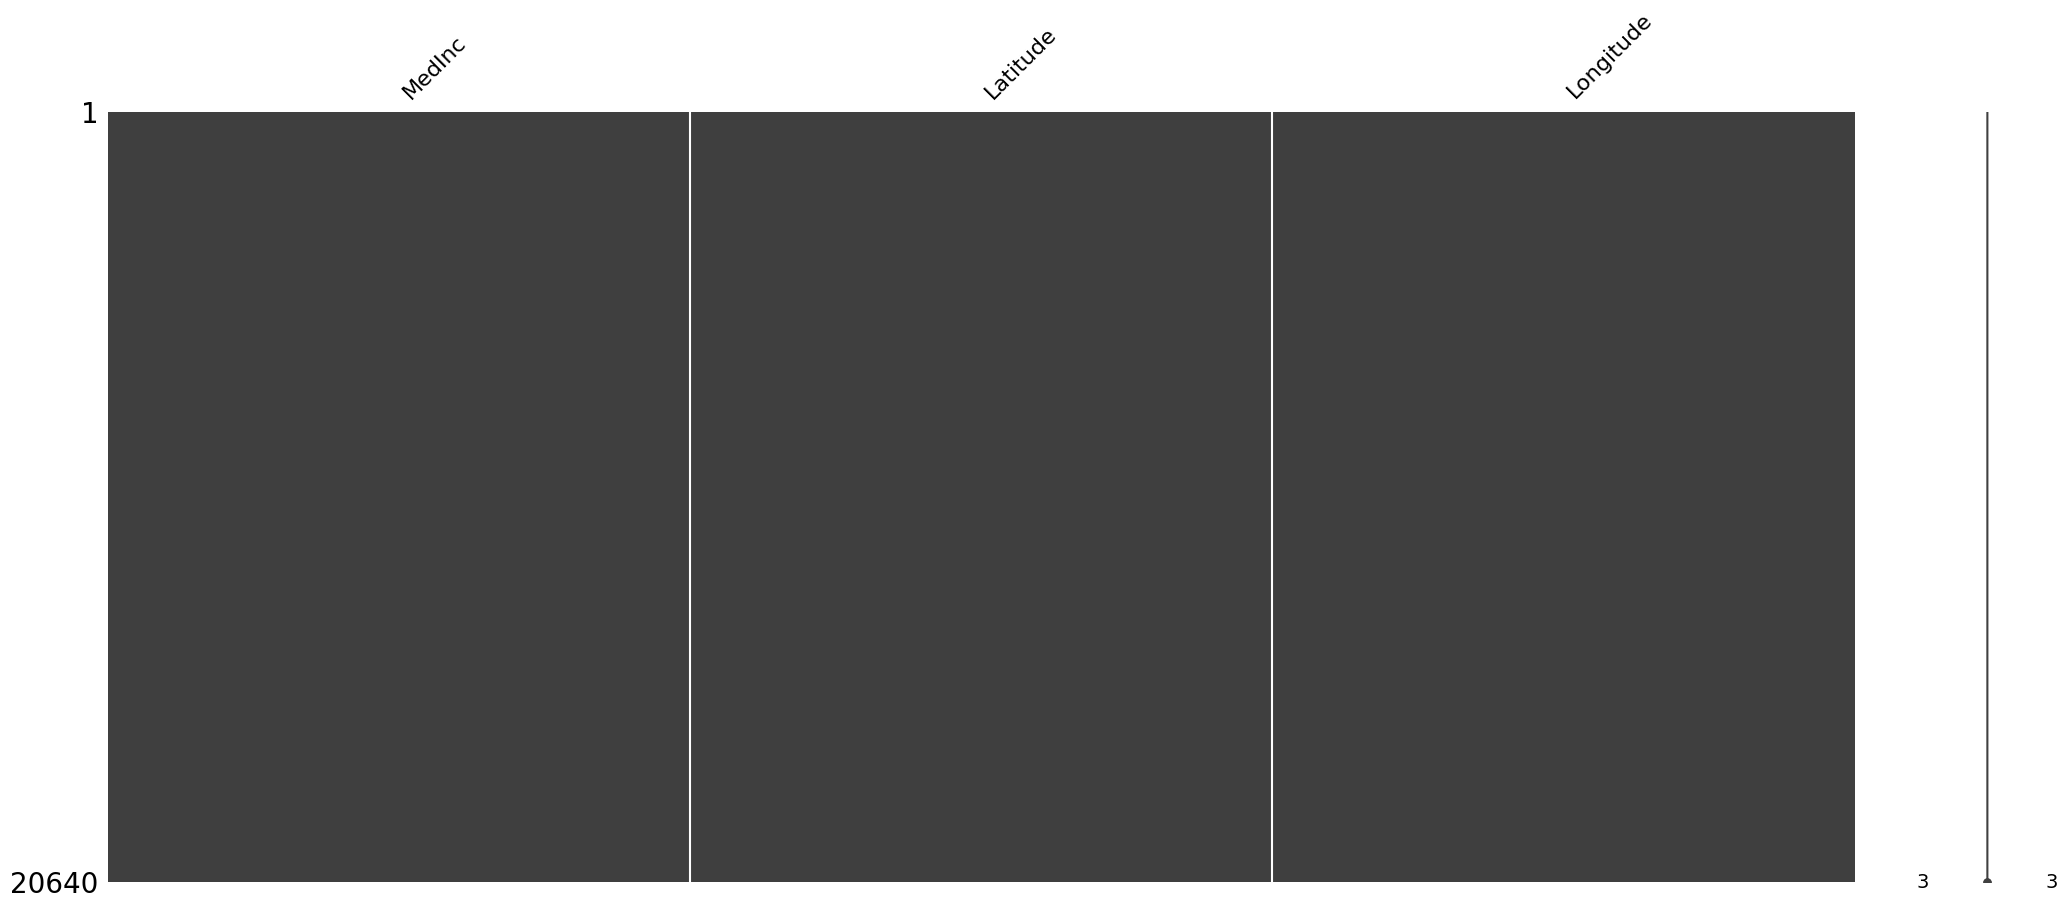

In [10]:
msno.matrix(df)
plt.show()

## 3.7 COMPROBACIÓN DE DATOS DUPLICADOS EN FILAS

In [11]:
filas_duplicadas = df[df.duplicated(keep=False)] # keep=False muestra TODAS las ocurrencias (incluyendo la original)

if len(filas_duplicadas) > 0:
    print(f"Se Encontraron {len(filas_duplicadas)} Filas Duplicadas:")
    print(f"Esto Representa {len(filas_duplicadas)/len(df)*100:.2f}% del DataSet\n")
    print(filas_duplicadas)
else:
    print("No hay Filas Duplicadas en el DataSet")

Se Encontraron 10 Filas Duplicadas:
Esto Representa 0.05% del DataSet

        MedInc  Latitude  Longitude
4569    2.3438     34.07    -118.27
4571    2.3438     34.07    -118.27
4605   15.0001     34.07    -118.33
4606   15.0001     34.07    -118.33
5291   15.0001     34.08    -118.42
8852   15.0001     34.08    -118.42
8853   15.0001     34.07    -118.41
8854   15.0001     34.07    -118.41
16328   4.3008     38.02    -121.33
16331   4.3008     38.02    -121.33


## 3.8 ELIMINAR FILAS DUPLICADAS 

In [12]:
df.drop_duplicates(keep='first', inplace=True)
df.duplicated().sum()

np.int64(0)

## 3.9 COMPROBACIÓN DE DATOS DUPLICADOS EN COLUMNAS CON LA TRANSPUESTA

In [13]:
columnas_duplicadas = df.T.duplicated(keep=False).sum()

if columnas_duplicadas > 0:
    print(f"\nSe Encontraron {columnas_duplicadas} Columnas Duplicadas")
    print("\nNombres de las Columnas Duplicadas:")
    print(df.T[df.T.duplicated(keep=False)].index)
else:
    print("\nNo hay Columnas Duplicadas en el DataSet")


No hay Columnas Duplicadas en el DataSet


# 4 DIVISIÓN DEL DATASET TRAIN-TEST

In [14]:
X = df
X_train, X_test = train_test_split(X, test_size = 0.2, random_state = 42)

print(f"Tamaño del conjunto de prueba: {len(X_test)}")
print(f"Tamaño del conjunto de entrenamiento: {len(X_train)}")

Tamaño del conjunto de prueba: 4127
Tamaño del conjunto de entrenamiento: 16508


# 5 ESCALAR DATOS 

In [15]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)  # Fit en train
X_test_scaled = scaler.transform(X_test)        # Solo transform en test

# 6 ENCONTRAR EL K ÓPTIMO

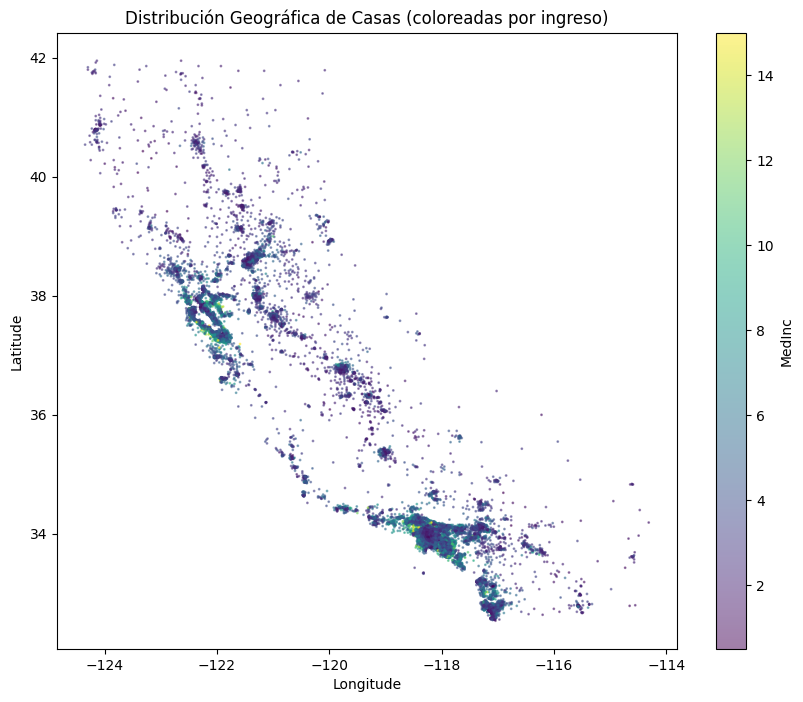

In [16]:
# Ver distribución de datos
# Scatter plot 2D (Latitude vs Longitude)
plt.figure(figsize=(10, 8))
plt.scatter(X_train['Longitude'], X_train['Latitude'], 
            c=X_train['MedInc'], cmap='viridis', alpha=0.5, s=1)
plt.colorbar(label='MedInc')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title('Distribución Geográfica de Casas (coloreadas por ingreso)')
plt.show()

1. INERCIA (¿Qué mide?)

La compacidad de los clusters: qué tan cerca están los puntos de su centroide.

Interpretación:

Inercia BAJA = Puntos muy juntos en cada cluster ✅

Inercia ALTA = Puntos dispersos ❌

2. SILHOUETTE (¿Qué mide?)

La calidad de la separación: qué tan bien están separados los clusters entre sí.

Interpretación:

Silhouette > 0.7  → Excelente separación 🌟

Silhouette 0.5-0.7 → Buena separación ✅

Silhouette 0.25-0.5 → Aceptable ⚠️

Silhouette < 0.25  → Mala separación ❌


#### He escogido este método porque:

- Inercia sola NO es suficiente:

Siempre mejora con más K,
No detecta sobre-segmentación.

- Silhouette complementa a Inercia:

Detecta cuando hay demasiados clusters,
Mide separación entre grupos,
Tiene un máximo claro (no siempre crece).

- Es el estándar en la industria:

Usado en Kaggle, empresas, papers académicos,
Sklearn lo incluye como métrica oficial,
Balanceado y confiable.

- Automatizado y objetivo

No depende de interpretación visual,
Decisión basada en números,
Reproducible y escalable.

In [17]:
# Bucle para encontrar K óptimo
print("="*70)
print("ANÁLISIS PARA ENCONTRAR K ÓPTIMO")
print("="*70)

# Probar rango de 2 a 12
K_range = range(2, 13)
results = []

for k in K_range:
    kmeans = KMeans(n_clusters=k, n_init="auto", random_state=42)
    kmeans.fit(X_train_scaled)
    
    silhouette = silhouette_score(X_train_scaled, kmeans.labels_)
    
    results.append({
        'K': k,
        'Inercia': kmeans.inertia_,
        'Silhouette': silhouette
    })
    
    print(f"K={k:2d} | Inercia={kmeans.inertia_:10.2f} | Silhouette={silhouette:.3f}")

# Convertir a DataFrame
df_results = pd.DataFrame(results)

# Encontrar K óptimo
best_k = df_results.loc[df_results['Silhouette'].idxmax(), 'K']
print("\n" + "="*70)
print(f"✅ K ÓPTIMO RECOMENDADO: {best_k}")
print(f"   Score Silhouette: {df_results.loc[df_results['Silhouette'].idxmax(), 'Silhouette']:.3f}")
print("="*70)

ANÁLISIS PARA ENCONTRAR K ÓPTIMO
K= 2 | Inercia=  21486.36 | Silhouette=0.548
K= 3 | Inercia=  15209.91 | Silhouette=0.517
K= 4 | Inercia=  12138.48 | Silhouette=0.457
K= 5 | Inercia=   9451.01 | Silhouette=0.388
K= 6 | Inercia=   8368.76 | Silhouette=0.347
K= 7 | Inercia=   7003.29 | Silhouette=0.369
K= 8 | Inercia=   6704.07 | Silhouette=0.329
K= 9 | Inercia=   6128.78 | Silhouette=0.331
K=10 | Inercia=   5506.42 | Silhouette=0.329
K=11 | Inercia=   4720.51 | Silhouette=0.350
K=12 | Inercia=   4456.44 | Silhouette=0.333

✅ K ÓPTIMO RECOMENDADO: 2
   Score Silhouette: 0.548


CONCLUSIÓN: EL K ÓPTIMO ES 2 PORQUE TIENE SILHOUETTE MAS ALTO, NOS DA UNA SEGMENTACIÓN CLARA NORTE VS SUR. TENER SOLO DOS GRUPOS ES MÁS INTERPRETABLE PARA NEGOCIOS Y SERIA UN BALANCE PERFECTO ENTRE SIMPLICIDAD Y PRECISIÓN.

# 7 CONSTRUCCIÓN DEL K-MEANS CON K=6 EXIGIDO EN EL EJERCICIO

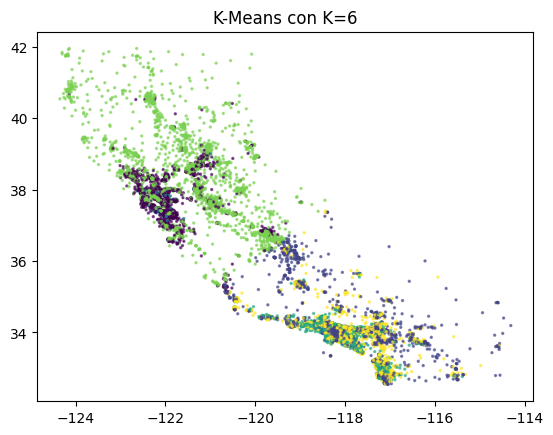

Centroides (desescalados):
      MedInc   Latitude   Longitude
0   5.394057  37.709806 -121.926467
1   2.357251  34.061455 -118.041574
2  11.454270  35.431955 -119.806282
3   6.488107  33.869264 -118.054795
4   2.741283  38.140032 -121.630615
5   4.143000  33.881996 -117.969807


In [ ]:
# 1. Entrenar con K=6
model_final = KMeans(n_clusters=6, n_init="auto", random_state=42)
model_final.fit(X_train_scaled)

# 2. Visualizar clusters 2D
labels = model_final.labels_
plt.scatter(X_train['Longitude'], X_train['Latitude'], 
            c=labels, cmap='viridis', alpha=0.6, s=2)
plt.title('K-Means con K=6')
plt.show()

# 3. Analizar centroides
centroides = scaler.inverse_transform(model_final.cluster_centers_)
print("Centroides (desescalados):")
print(pd.DataFrame(centroides, columns=['MedInc', 'Latitude', 'Longitude']))

C:\Users\ingen\AppData\Local\Temp\ipykernel_6408\964198523.py:26: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


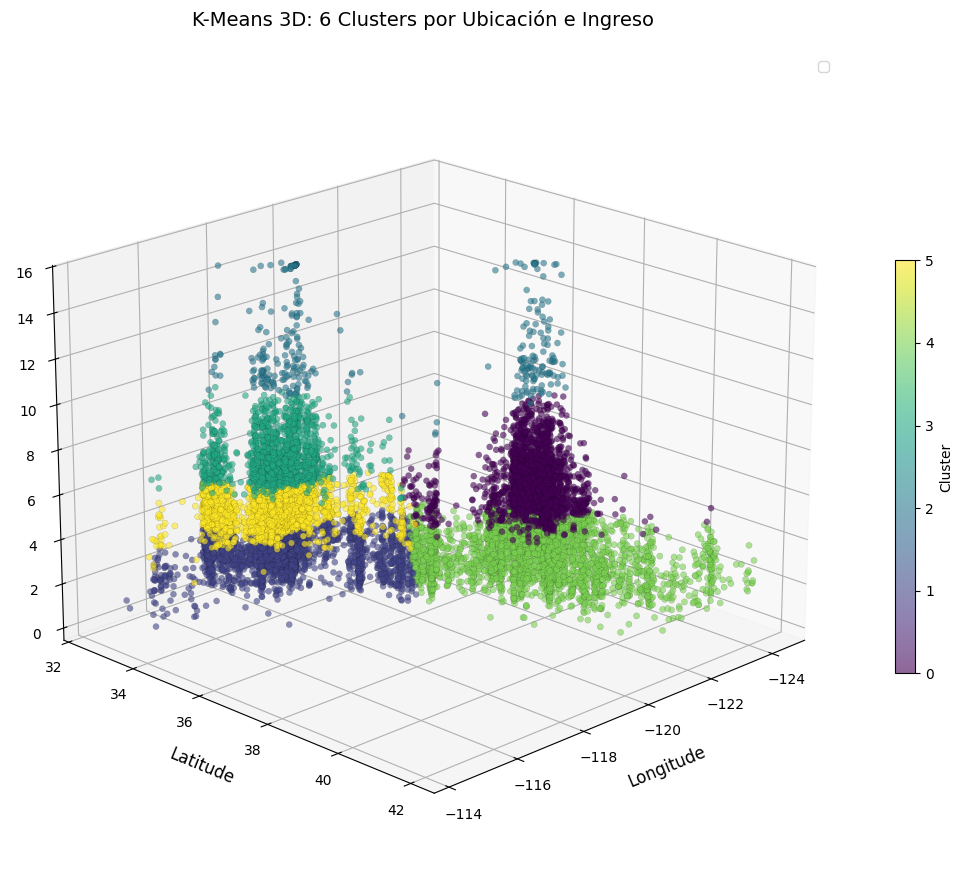

In [32]:
from mpl_toolkits.mplot3d import Axes3D

# Crear figura 3D
fig = plt.figure(figsize=(12, 9))
ax = fig.add_subplot(111, projection='3d')

# Scatter plot 3D con los clusters
scatter = ax.scatter(X_train['Longitude'], 
                     X_train['Latitude'], 
                     X_train['MedInc'],
                     c=labels, 
                     cmap='viridis', 
                     alpha=0.6, 
                     s=20,
                     edgecolors='k',
                     linewidth=0.1)

# Etiquetas y título
ax.set_xlabel('Longitude', fontsize=12, labelpad=10)
ax.set_ylabel('Latitude', fontsize=12, labelpad=10)
ax.set_zlabel('MedInc', fontsize=12, labelpad=10)
ax.set_title('K-Means 3D: 6 Clusters por Ubicación e Ingreso', fontsize=14, pad=20)

# Colorbar
plt.colorbar(scatter, ax=ax, label='Cluster', shrink=0.5)
ax.legend()

# Ajustar ángulo de vista para mejor perspectiva
ax.view_init(elev=20, azim=45)

plt.tight_layout()
plt.show()

# 8 INSERTAR COLUMNA Y_TRAIN 

In [19]:
y_train = list(model_final.labels_)
X_train["cluster"] = y_train
X_train.head()

,MedInc,Latitude,Longitude,cluster
19985,3.1453,36.20,-119.31,1
11235,5.2384,33.81,-117.96,5
2271,3.5542,36.78,-119.80,4
8660,4.3594,33.85,-118.39,5
6250,3.4722,34.04,-117.98,5


## 8.1 GRÁFICA

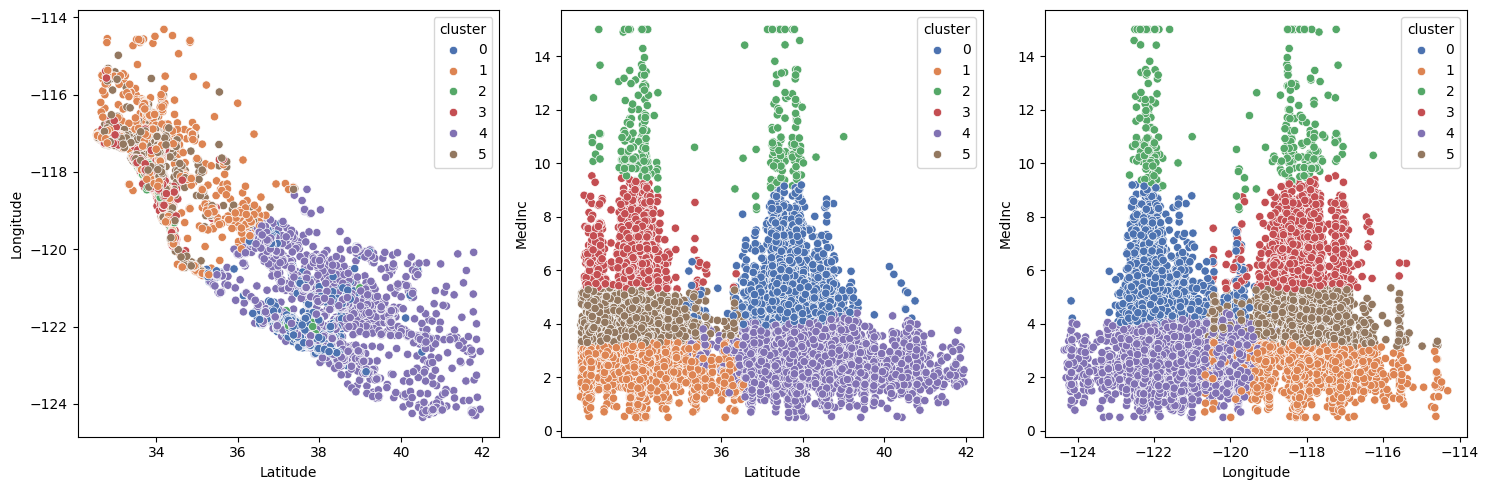

In [20]:
# Visualización de clusters en diferentes combinaciones de características
fig, axis = plt.subplots(1, 3, figsize = (15, 5))

sns.scatterplot(ax = axis[0], data = X_train, x = "Latitude", y = "Longitude", hue = "cluster", palette = "deep")
sns.scatterplot(ax = axis[1], data = X_train, x = "Latitude", y = "MedInc", hue = "cluster", palette = "deep")
sns.scatterplot(ax = axis[2], data = X_train, x = "Longitude", y = "MedInc", hue = "cluster", palette = "deep")
plt.tight_layout()

plt.show()

# 9 INSERTAR COLUMNA Y_TEST 

In [21]:
y_test = list(model_final.predict(X_test_scaled))
X_test["cluster"] = y_test
X_test.head()

,MedInc,Latitude,Longitude,cluster
8572,8.4680,33.90,-118.41,3
1712,3.9722,37.97,-122.32,4
15916,3.4583,37.74,-122.42,4
5196,1.6625,33.94,-118.27,1
13583,1.5156,34.13,-117.29,1


## 9.1 GRÁFICA

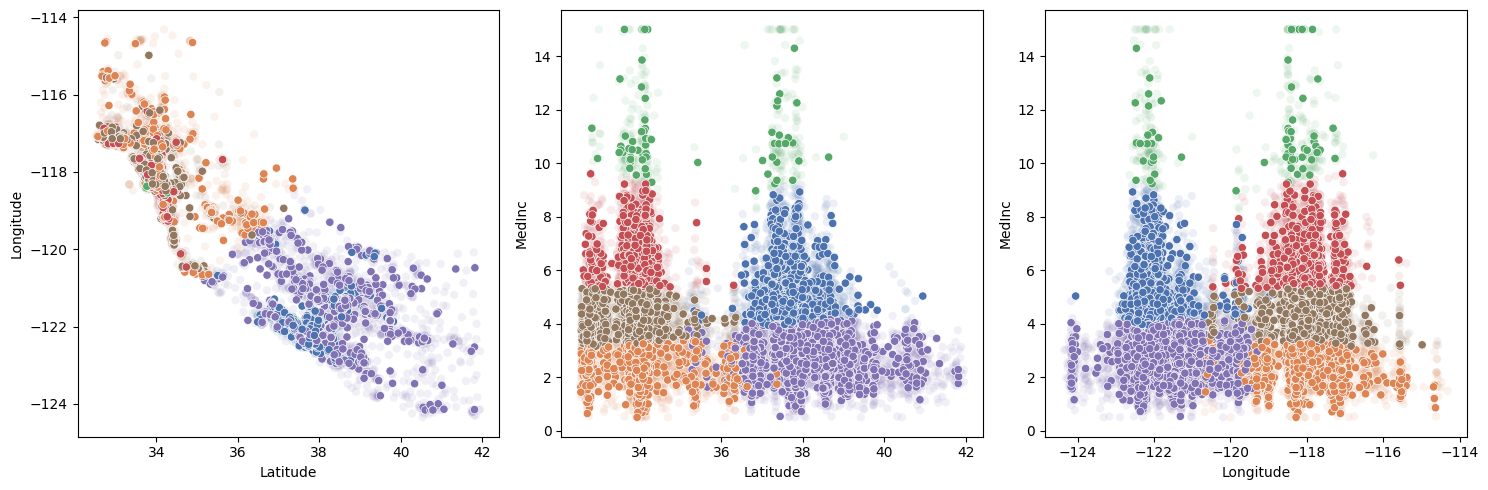

In [22]:
fig, axis = plt.subplots(1, 3, figsize = (15, 5))

sns.scatterplot(ax = axis[0], data = X_train, x = "Latitude", y = "Longitude", hue = "cluster", palette = "deep", alpha  = 0.1)
sns.scatterplot(ax = axis[1], data = X_train, x = "Latitude", y = "MedInc", hue = "cluster", palette = "deep", alpha  = 0.1)
sns.scatterplot(ax = axis[2], data = X_train, x = "Longitude", y = "MedInc", hue = "cluster", palette = "deep", alpha  = 0.1)

sns.scatterplot(ax = axis[0], data = X_test, x = "Latitude", y = "Longitude", hue = "cluster", palette = "deep")
sns.scatterplot(ax = axis[1], data = X_test, x = "Latitude", y = "MedInc", hue = "cluster", palette = "deep")
sns.scatterplot(ax = axis[2], data = X_test, x = "Longitude", y = "MedInc", hue = "cluster", palette = "deep")

plt.tight_layout()

for ax in axis:
    ax.legend([],[], frameon=False)

plt.show()

# 10 APLICACIÓN DE MODELO DE PREDICCIÓN

In [23]:
## Eliminamos la columna 'cluster' de los datasets de entrenamiento y prueba
X_train.drop(columns=["cluster"], inplace=True)
X_test.drop(columns=["cluster"], inplace=True)
X_train.head()

,MedInc,Latitude,Longitude
19985,3.1453,36.20,-119.31
11235,5.2384,33.81,-117.96
2271,3.5542,36.78,-119.80
8660,4.3594,33.85,-118.39
6250,3.4722,34.04,-117.98


In [24]:
model_sup = DecisionTreeClassifier(random_state = 42)
model_sup.fit(X_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [25]:
# Hacer predicciones con el modelo
y_pred_train = model_sup.predict(X_train)
y_pred_test = model_sup.predict(X_test)

print(f"✅ Predicciones generadas:")
print(f"   Train: {len(y_pred_train)} predicciones")
print(f"   Test: {len(y_pred_test)} predicciones")

✅ Predicciones generadas:
   Train: 16508 predicciones
   Test: 4127 predicciones


In [26]:
text_representation = export_text(model_sup, feature_names=list(X_train.columns), show_weights=True)
print(text_representation)

|--- Latitude <= 36.34
|   |--- MedInc <= 3.25
|   |   |--- Longitude <= -120.67
|   |   |   |--- Latitude <= 35.25
|   |   |   |   |--- Longitude <= -120.69
|   |   |   |   |   |--- weights: [0.00, 0.00, 0.00, 0.00, 1.00, 0.00] class: 4
|   |   |   |   |--- Longitude >  -120.69
|   |   |   |   |   |--- weights: [0.00, 2.00, 0.00, 0.00, 0.00, 0.00] class: 1
|   |   |   |--- Latitude >  35.25
|   |   |   |   |--- MedInc <= 1.71
|   |   |   |   |   |--- Longitude <= -120.79
|   |   |   |   |   |   |--- weights: [0.00, 0.00, 0.00, 0.00, 1.00, 0.00] class: 4
|   |   |   |   |   |--- Longitude >  -120.79
|   |   |   |   |   |   |--- weights: [0.00, 1.00, 0.00, 0.00, 0.00, 0.00] class: 1
|   |   |   |   |--- MedInc >  1.71
|   |   |   |   |   |--- weights: [0.00, 0.00, 0.00, 0.00, 30.00, 0.00] class: 4
|   |   |--- Longitude >  -120.67
|   |   |   |--- MedInc <= 3.16
|   |   |   |   |--- Longitude <= -119.60
|   |   |   |   |   |--- Latitude <= 35.40
|   |   |   |   |   |   |--- Longitude <=

In [27]:
# NOTA: Para clasificación multiclase (6 clusters), usamos 'average' para las métricas
def get_metrics(y_train, y_test, y_pred_train, y_pred_test):
    # Calcular métricas para el conjunto de entrenamiento (multiclase)
    train_accuracy = accuracy_score(y_train, y_pred_train)
    train_f1 = f1_score(y_train, y_pred_train, average='weighted')
    train_precision = precision_score(y_train, y_pred_train, average='weighted')
    train_recall = recall_score(y_train, y_pred_train, average='weighted')

    # Calcular métricas para el conjunto de prueba (multiclase)
    test_accuracy = accuracy_score(y_test, y_pred_test)
    test_f1 = f1_score(y_test, y_pred_test, average='weighted')
    test_precision = precision_score(y_test, y_pred_test, average='weighted')
    test_recall = recall_score(y_test, y_pred_test, average='weighted')

    # Calcular la diferencia entre métricas de entrenamiento y prueba
    diff_accuracy = train_accuracy - test_accuracy
    diff_f1 = train_f1 - test_f1
    diff_precision = train_precision - test_precision
    diff_recall = train_recall - test_recall

    # Crear un DataFrame con los resultados
    metrics_df = pd.DataFrame([
        [train_accuracy, train_f1, train_precision, train_recall],
        [test_accuracy, test_f1, test_precision, test_recall],
        [diff_accuracy, diff_f1, diff_precision, diff_recall]
    ],
        columns = ['Accuracy', 'F1', 'Precision', 'Recall'],
        index = ['Train','Test', 'Diferencia'])

    return metrics_df

In [28]:
get_metrics(y_train, y_test,y_pred_train, y_pred_test)

,Accuracy,F1,Precision,Recall
Train,1.000000,1.000000,1.000000,1.000000
Test,0.991277,0.991275,0.991287,0.991277
Diferencia,0.008723,0.008725,0.008713,0.008723


# 10 GUARDAR O EXPORTAR EL MODELO

In [29]:
joblib.dump(model_sup, 'modelo_clasificación_casas_.pkl')
print("✅ Modelo guardado exitosamente como 'modelo_clasificación_casas_.pkl'")

✅ Modelo guardado exitosamente como 'modelo_clasificación_casas_.pkl'


In [30]:
# Cargamos el modelo
modelo_final = joblib.load('modelo_clasificación_casas_.pkl')